In [1]:
from pathlib import Path
import pandas as pd
import pymupdf

from dsa.constants import ROOT
from dsa.utils import load_json
from scripts.visualize_pages import _group_pages_by_doc

In [2]:
def get_page_count(fp):
    with pymupdf.open(fp) as doc:
        page_count = doc.page_count
    return page_count

In [3]:
def generate_corpus_stats(gt_json_path, pdf_input_dir):
    gt = load_json(gt_json_path)
    gpbd = _group_pages_by_doc(gt["predictions"])

    # Create dict: {doc_name: [n_pages_w_snapshots, total_pages]}
    docs = {k: [len(v), get_page_count(pdf_input_dir / k)] for k, v in gpbd.items()}
    
    df = pd.DataFrame.from_dict(
        docs, orient="index", columns=["n_pages_w_snapshots", "total_pages"]
    )
    df["ratio"] = df["n_pages_w_snapshots"] / df["total_pages"]

    return df

In [4]:
gt_json_path = ROOT / "data/paper/evaluation_input/gt/ground_truth_prwp_combined.json"
pdf_input_dir = ROOT / "../hf_datasets/data-snapshot/documents/prwp/"
prwp = generate_corpus_stats(gt_json_path, pdf_input_dir)

gt_json_path = ROOT / "data/paper/evaluation_input/gt/ground_truth_refugee_combined.json"
pdf_input_dir = ROOT / "../hf_datasets/data-snapshot/documents/refugee/"
refugee = generate_corpus_stats(gt_json_path, pdf_input_dir)

df = pd.concat([prwp, refugee])
df

,n_pages_w_snapshots,total_pages,ratio
document_11696987.pdf,6,29,0.206897
document_700561.pdf,11,40,0.275000
document_11670035.pdf,4,40,0.100000
document_10455617.pdf,11,20,0.550000
document_14491760.pdf,3,22,0.136364
...,...,...,...
002_BOSIB-ca473522-8ad0-4c80-9f0d-88bf887f2a2f.pdf,9,51,0.176471
069_Pakistan-Strengthening-Institutions-for-Refugee-Administration-Project.pdf,18,48,0.375000
199_multi0page.pdf,17,47,0.361702
010_BOSIB1554c314c0a2187c019d7e85bc2a91.pdf,6,49,0.122449


In [5]:
print("PRWP:")
print(f"Average % of pages with snapshots: {100 * prwp['ratio'].mean():.2f}")
print(f"Median % of pages with snapshots: {100 * prwp['ratio'].median():.2f}")

print("\nRefugee:")
print(f"Average % of pages with snapshots: {100 * refugee['ratio'].mean():.2f}")
print(f"Median % of pages with snapshots: {100 * refugee['ratio'].median():.2f}")

print("\nCombined:")
print(f"Average % of pages with snapshots: {100 * df['ratio'].mean():.2f}")
print(f"Median % of pages with snapshots: {100 * df['ratio'].median():.2f}")

PRWP:
Average % of pages with snapshots: 27.80
Median % of pages with snapshots: 23.43

Refugee:
Average % of pages with snapshots: 22.99
Median % of pages with snapshots: 21.21

Combined:
Average % of pages with snapshots: 26.35
Median % of pages with snapshots: 22.72


# Histograms

In [6]:
import plotly.express as px
from plotly.subplots import make_subplots

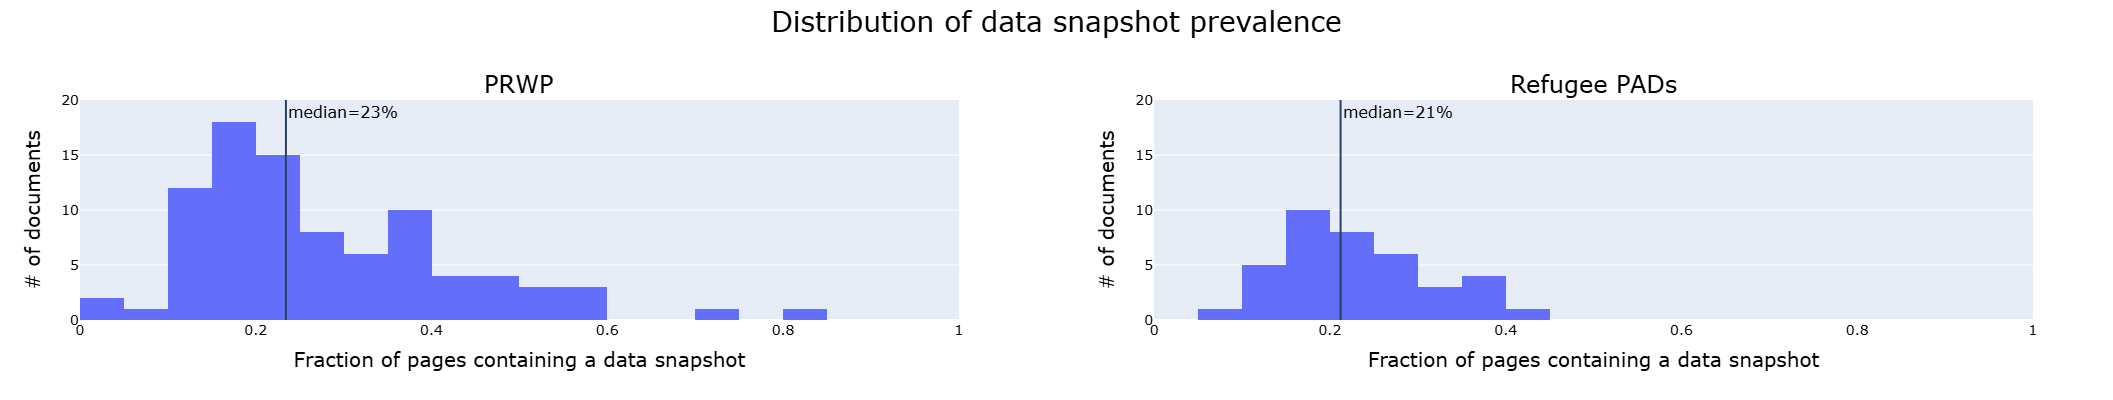

In [79]:
# Create base figs
fig1 = px.histogram(data_frame=prwp, x="ratio", range_x=[0, 1])
fig2 = px.histogram(data_frame=refugee, x="ratio", range_x=[0, 1])

# Create combined fig
combined_fig = make_subplots(rows=1, cols=2, subplot_titles=("PRWP", "Refugee PADs"))
for trace in fig1.data:
    combined_fig.add_trace(trace, row=1, col=1)
for trace in fig2.data:
    combined_fig.add_trace(trace, row=1, col=2)

# Add vlines
val = prwp["ratio"].median()
combined_fig.add_vline(
    x=val,
    annotation_text=f"median={val:.0%}",
    annotation_font_size=16,
    annotation_font_color="black",
    row=1,
    col=1,
)
val = refugee["ratio"].median()
combined_fig.add_vline(
    x=val,
    annotation_text=f"median={val:.0%}",
    annotation_font_size=16,
    annotation_font_color="black",
    row=1,
    col=2,
)

# Update elements
combined_fig.update_layout(
    title_text="Distribution of data snapshot prevalence",
    height=400,
    width=1200,
    title_font_size=28,
    font=dict(color="black"),
    title_y=0.97,
    title_x=0.5,
    title_xanchor='center',
)
combined_fig.update_xaxes(
    title_text="Fraction of pages containing a data snapshot",
    range=[0, 1],
    title_font_size=20,
    tickfont_size=14,
)
combined_fig.update_yaxes(
    title_text="# of documents",
    range=[0, 20],
    title_font_size=20,
    tickfont_size=14,
)
combined_fig.for_each_annotation(
    lambda a: a.update(font=dict(size=24)) if "median" not in a.text else None
)

combined_fig.show()